ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

### Part 1: Setup and Data Quality Assessment (Task 1)
This section loads the submission.csv dataset and identifies logical errors, such as the 180 phones with a screen width (sc_w) of 0.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Set visualization style
sns.set(style="whitegrid")

# Load the dataset
df = pd.read_csv('submission.csv')

# Task 1: Identify Data Quality Issues
print("--- Data Types ---")
print(df.dtypes)

# Check for logically inconsistent 0 values
zero_px_height = (df['px_height'] == 0).sum()
zero_sc_w = (df['sc_w'] == 0).sum()

print(f"\nIssues Identified:")
print(f"- px_height with 0 value: {zero_px_height} records")
print(f"- sc_w (screen width) with 0 value: {zero_sc_w} records")

--- Data Types ---
battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

Issues Identified:
- px_height with 0 value: 2 records
- sc_w (screen width) with 0 value: 180 records


### Part 2: Handling Missing Values (Task 2)
Following the lab instructions, we introduce artificial missing values into the ram column and fix them using Median Imputation because the data range is wide.

In [8]:
# Task 2: Simulate Missing Data and Apply Median Imputation
# We will "delete" data in 20 random rows to simulate missing values
np.random.seed(42) # Ensures the same 20 rows are chosen every time you run the code
missing_indices = np.random.choice(df.index, 20, replace=False)

# Assigning np.nan effectively "deletes" the values in those 20 rows
df.loc[missing_indices, 'ram'] = np.nan

print(f"Number of missing values created in 'ram': {df['ram'].isna().sum()}")

# Strategy: Median Imputation
# Why? The median is the middle value and is more robust against potential outliers.
ram_median = df['ram'].median()
df['ram'] = df['ram'].fillna(ram_median)

print(f"Missing values in 'ram' after fixing: {df['ram'].isna().sum()}")

Number of missing values created in 'ram': 20
Missing values in 'ram' after fixing: 0


### Part 3: Handling Outliers (Task 3)
We use the Interquartile Range (IQR) method to detect extreme values in px_height. 2 outliers are removed to ensure the model remains accurate.

Original records: 2000
Records after outlier removal: 1998


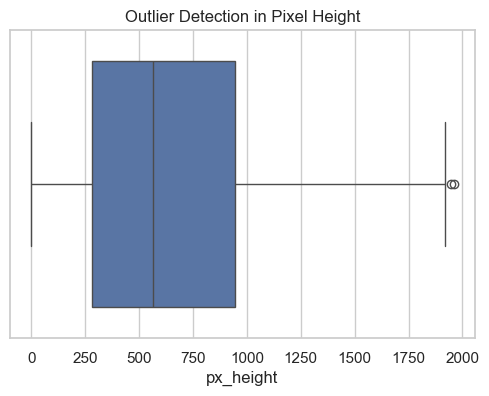

In [9]:
# Task 3: Detect and Handle Outliers using IQR
Q1 = df['px_height'].quantile(0.25)
Q3 = df['px_height'].quantile(0.75)
IQR = Q3 - Q1

# Define the acceptable range
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# Remove outliers from the dataframe
df_clean = df[(df['px_height'] >= lower_limit) & (df['px_height'] <= upper_limit)]

print(f"Original records: {len(df)}")
print(f"Records after outlier removal: {len(df_clean)}")

# Visualization
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['px_height'])
plt.title("Outlier Detection in Pixel Height")
plt.show()

### Part 4: Data Transformation - Normalization (Task 4)
This step rescales the features so that different units (like RAM in MB vs. Battery in mAh) can be compared fairly.

In [10]:
# Task 4: Normalize numerical features
# Selecting continuous variables for scaling
features_to_scale = ['battery_power', 'ram', 'px_width', 'px_height', 'mobile_wt']
subset = df_clean[features_to_scale]

# 1. Min-Max Normalization (Scales to 0-1)
min_max_scaler = MinMaxScaler()
df_min_max = pd.DataFrame(min_max_scaler.fit_transform(subset), columns=features_to_scale)

# 2. Z-Score Normalization (Standardization: Mean=0, StdDev=1)
std_scaler = StandardScaler()
df_std = pd.DataFrame(std_scaler.fit_transform(subset), columns=features_to_scale)

print("Standardized Data (First 5 rows):")
print(df_std.head())

Standardized Data (First 5 rows):
   battery_power       ram  px_width  px_height  mobile_wt
0      -0.901993  0.394911 -1.146153  -1.411458   1.348233
1      -0.494722  0.470851  1.707718   0.591020  -0.120978
2      -1.536789  0.444920  1.077642   1.401062   0.133309
3      -1.418476  0.598653  1.239794   1.294715  -0.262248
4       1.325484 -0.658991 -0.089850   1.276614   0.020293


### Part 5: Data Reduction - PCA (Task 5)
Finally, we apply Principal Component Analysis to find the components that capture the most variance (information) in the dataset.

Explained Variance per Component: [0.30180586 0.20067392 0.19986699 0.19961287 0.09804036]
Total Variance captured by first 2 components: 50.25%


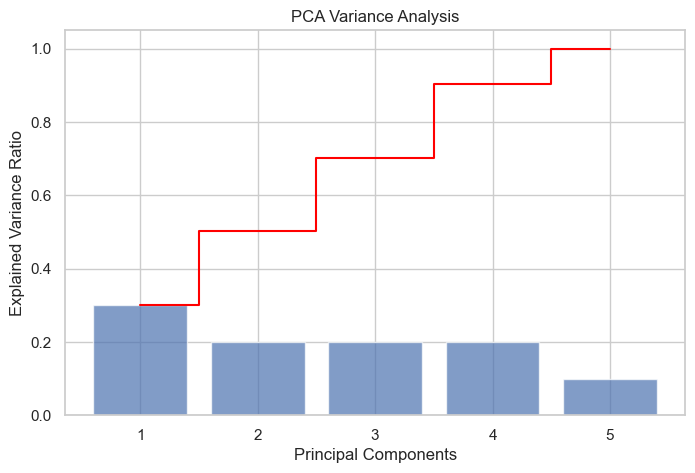

In [11]:
# Task 5: Apply PCA and Interpret Explained Variance
pca = PCA(n_components=None)
pca_results = pca.fit(df_std)

# Capture the Explained Variance Ratio
var_ratio = pca_results.explained_variance_ratio_

print(f"Explained Variance per Component: {var_ratio}")
print(f"Total Variance captured by first 2 components: {sum(var_ratio[:2]):.2%}")

# Scree Plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(var_ratio) + 1), var_ratio, alpha=0.7, align='center')
plt.step(range(1, len(var_ratio) + 1), np.cumsum(var_ratio), where='mid', color='red')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('PCA Variance Analysis')
plt.show()

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of lab 4.